# Data and Library Preparation

In [ ]:
import sys
from pathlib import Path

# Add parent directory of "a" to sys.path
sys.path.append(str(Path.cwd().parent.parent.parent))

In [ ]:
import numpy as np
import pandas as pd
from CODECbreakCode.AudioMixer import SingleFileAudioMixer
import CODECbreakCode.Evaluator as Evaluator
from CODECbreakCode.Evaluator import MeasureHAAQIOutput
import argparse
import signalcomparison as sc
import signalmaskcomparison as smc
import os
import re
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Audio

import rich
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Original Reading Fold
MusicMix_Mixing_Path = './Experiment.A.Audio/'
## Degradation Configuration
solution = [15,30,2,-15,10,0.1,50]

## Gererating MP3

### Clean MP3

In [3]:
MusicMix_Noise_Generator_MP3 = SingleFileAudioMixer(MusicMix_Mixing_Path,"TestTone_testtone_8s.wav")
MusicMix_Referece_File,_ = MusicMix_Noise_Generator_MP3.TestDynNoisedFullTrack([0]*7,"Reference_IN_TestTone_testtone_8s.wav")
print(f"Referece_File:{MusicMix_Referece_File}")
Referece_MP3File = Evaluator.Mp3LameLossyCompress(MusicMix_Referece_File,64)
print(f"Reggae_Referece_Mp3File:{Referece_MP3File}")
####initalise the Haaqi
MeasureHAAQI = MeasureHAAQIOutput(Referece_MP3File)#Initilize the HAAQI with a permanent reference
MeasureHAAQI.MeasureHAQQIOutput(Referece_MP3File) #Test on how far from itself to itself

Audio duration orginal is 8.0 seconds
Referece_File:./Experiment.A.Audio//Mixing_Result/Reference_IN_TestTone_testtone_8s.wav
Reggae_Referece_Mp3File:./Experiment.A.Audio/Mixing_Result_Mp3_Wav/Reference_IN_TestTone_testtone_8s_64kbps.wav


0.6207050191365489

In [7]:
acuum_spl_orig_wav, accum_global_mask_wav, accum_noise_mask_wav, accum_tone_mask_wav, acuum_mask_degr_wav, acuum_smr_orig_wav,block_index_wav = smc.generate_mask(MusicMix_Referece_File)
acuum_spl_orig_mp3, accum_global_mask_mp3, accum_noise_mask_mp3, accum_tone_mask_mp3, acuum_mask_degr_mp3, acuum_smr_orig_mp3, block_index_mp3 = smc.generate_mask(Referece_MP3File)

### Clean Mp3 Adding degradation

In [9]:
degradated_filename = "worst_testtone_degraded.wav"
gener_Audio,_ = MusicMix_Noise_Generator_MP3.TestDynNoisedFullTrack(solution,degradated_filename)
gener_Audio_mp3 = Evaluator.Mp3LameLossyCompress(gener_Audio, 64)
score = MeasureHAAQI.MeasureHAQQIOutput(gener_Audio_mp3)
1-score

/root/anaconda3/envs/codecbreak/lib/python3.10/site-packages/audiomentations/core/transforms_interface.py:107: UserWarning: Warning: input samples dtype is np.float64. Converting to np.float32
  warnings.warn(


0.7259485721888912

In [10]:
acuum_spl_orig_wav_deg, accum_global_mask_wav_deg, accum_noise_mask_wav_deg, accum_tone_mask_wav_deg, acuum_mask_degr_wav_deg, acuum_smr_orig_wav_deg,block_index_wav_deg = smc.generate_mask(gener_Audio)
acuum_spl_orig_mp3_deg, accum_global_mask_mp3_deg, accum_noise_mask_mp3_deg, accum_tone_mask_mp3_deg, acuum_mask_degr_mp3_deg, acuum_smr_orig_mp3_deg, block_index_mp3_deg = smc.generate_mask(gener_Audio_mp3)

## Gererating AAC

### Clean AAC

In [12]:
MusicMix_Noise_Generator_AAC = SingleFileAudioMixer(MusicMix_Mixing_Path,"TestTone_testtone_8s.wav")
MusicMix_Referece_File,_ = MusicMix_Noise_Generator_AAC.TestDynNoisedFullTrack([0]*7,"Reference_IN_TestTone_testtone_8s.wav")
print(f"Referece_File:{MusicMix_Referece_File}")
Referece_AACFile = Evaluator.AacLameLossyCompress(MusicMix_Referece_File,64)
print(f"Reggae_Referece_AACFile:{Referece_AACFile}")
####initalise the Haaqi
MeasureHAAQI = MeasureHAAQIOutput(Referece_AACFile)#Initilize the HAAQI with a permanent reference
MeasureHAAQI.MeasureHAQQIOutput(Referece_AACFile) #Test on how far from itself to itself

Audio duration orginal is 8.0 seconds
Referece_File:./Experiment.A.Audio//Mixing_Result/Reference_IN_TestTone_testtone_8s.wav
Reggae_Referece_AACFile:./Experiment.A.Audio/Mixing_Result_AAC_Wav/Reference_IN_TestTone_testtone_8s_64kbps.wav


0.6473835587664263

In [13]:
acuum_spl_orig_wav, accum_global_mask_wav, accum_noise_mask_wav, accum_tone_mask_wav, acuum_mask_degr_wav, acuum_smr_orig_wav,block_index_wav = smc.generate_mask(MusicMix_Referece_File)
acuum_spl_orig_aac, accum_global_mask_aac, accum_noise_mask_aac, accum_tone_mask_aac, acuum_mask_degr_aac, acuum_smr_orig_aac, block_index_aac = smc.generate_mask(Referece_AACFile)

### Clean AAC Adding degradation

In [14]:
degradated_filename = "worst_testtone_degraded.wav"
gener_Audio,_ = MusicMix_Noise_Generator_AAC.TestDynNoisedFullTrack(solution,degradated_filename)
gener_Audio_aac = Evaluator.AacLameLossyCompress(gener_Audio, 64)
score = MeasureHAAQI.MeasureHAQQIOutput(gener_Audio_aac)
1-score

/root/anaconda3/envs/codecbreak/lib/python3.10/site-packages/audiomentations/core/transforms_interface.py:107: UserWarning: Warning: input samples dtype is np.float64. Converting to np.float32
  warnings.warn(


0.7106937976136037

In [15]:
acuum_spl_orig_wav_deg, accum_global_mask_wav_deg, accum_noise_mask_wav_deg, accum_tone_mask_wav_deg, acuum_mask_degr_wav_deg, acuum_smr_orig_wav_deg,block_index_wav_deg = smc.generate_mask(gener_Audio)
acuum_spl_orig_aac_deg, accum_global_mask_aac_deg, accum_noise_mask_aac_deg, accum_tone_mask_aac_deg, acuum_mask_degr_aac_deg, acuum_smr_orig_aac_deg, block_index_aac_deg = smc.generate_mask(gener_Audio_aac)

## EnCODEC

### Clean EnCODEC

In [16]:
MusicMix_Noise_Generator_Neural = SingleFileAudioMixer(MusicMix_Mixing_Path,"TestTone_testtone_8s.wav")
MusicMix_Referece_File,_ = MusicMix_Noise_Generator_Neural.TestDynNoisedFullTrack([0]*7,"Reference_IN_TestTone_testtone_8s.wav")
print(f"Referece_File:{MusicMix_Referece_File}")
Referece_NeuralFile = Evaluator.NeuralCodecCompress(MusicMix_Referece_File)
print(f"Reggae_Referece_NCFile:{Referece_NeuralFile}")
####initalise the Haaqi
MeasureHAAQI = MeasureHAAQIOutput(Referece_NeuralFile)#Initilize the HAAQI with a permanent reference
MeasureHAAQI.MeasureHAQQIOutput(Referece_NeuralFile) #Test on how far from itself to itself

Audio duration orginal is 8.0 seconds
Referece_File:./Experiment.A.Audio//Mixing_Result/Reference_IN_TestTone_testtone_8s.wav
Reggae_Referece_NCFile:/home/codecrack/CodecBreakerwithRL/Exp.3.CODECFight/Paper_Code_Effect_of_Degradations_on_CODECs/Experiment.A/Experiment.A.Audio/Mixing_Result_NeuralCodec_Wav/Reference_IN_TestTone_testtone_8s_24kbps.wav


0.9664857941017139

In [17]:
acuum_spl_orig_wav, accum_global_mask_wav, accum_noise_mask_wav, accum_tone_mask_wav, acuum_mask_degr_wav, acuum_smr_orig_wav,block_index_wav = smc.generate_mask(str(MusicMix_Referece_File))
acuum_spl_orig_nc, accum_global_mask_nc, accum_noise_mask_nc, accum_tone_mask_nc, acuum_mask_degr_nc, acuum_smr_orig_nc, block_index_nc = smc.generate_mask(str(Referece_NeuralFile))

### Clean Neural CODEC Adding degradation

In [18]:
degradated_filename = "worst_testtone_degraded.wav"
gener_Audio,_ = MusicMix_Noise_Generator_Neural.TestDynNoisedFullTrack(solution,degradated_filename)
gener_Audio_Neural = Evaluator.NeuralCodecCompress(gener_Audio)
score = MeasureHAAQI.MeasureHAQQIOutput(gener_Audio_Neural)
1-score

/root/anaconda3/envs/codecbreak/lib/python3.10/site-packages/audiomentations/core/transforms_interface.py:107: UserWarning: Warning: input samples dtype is np.float64. Converting to np.float32
  warnings.warn(


0.747029825264559

In [19]:
acuum_spl_orig_wav_deg, accum_global_mask_wav_deg, accum_noise_mask_wav_deg, accum_tone_mask_wav_deg, acuum_mask_degr_wav_deg, acuum_smr_orig_wav_deg,block_index_wav_deg = smc.generate_mask(str(gener_Audio))
acuum_spl_orig_nc_deg, accum_global_mask_nc_deg, accum_noise_mask_nc_deg, accum_tone_mask_nc_deg, acuum_mask_degr_nc_deg, acuum_smr_orig_nc_deg, block_index_nc_deg = smc.generate_mask(str(gener_Audio_Neural))

# Plot

## Clean Plot

### Full Figures

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


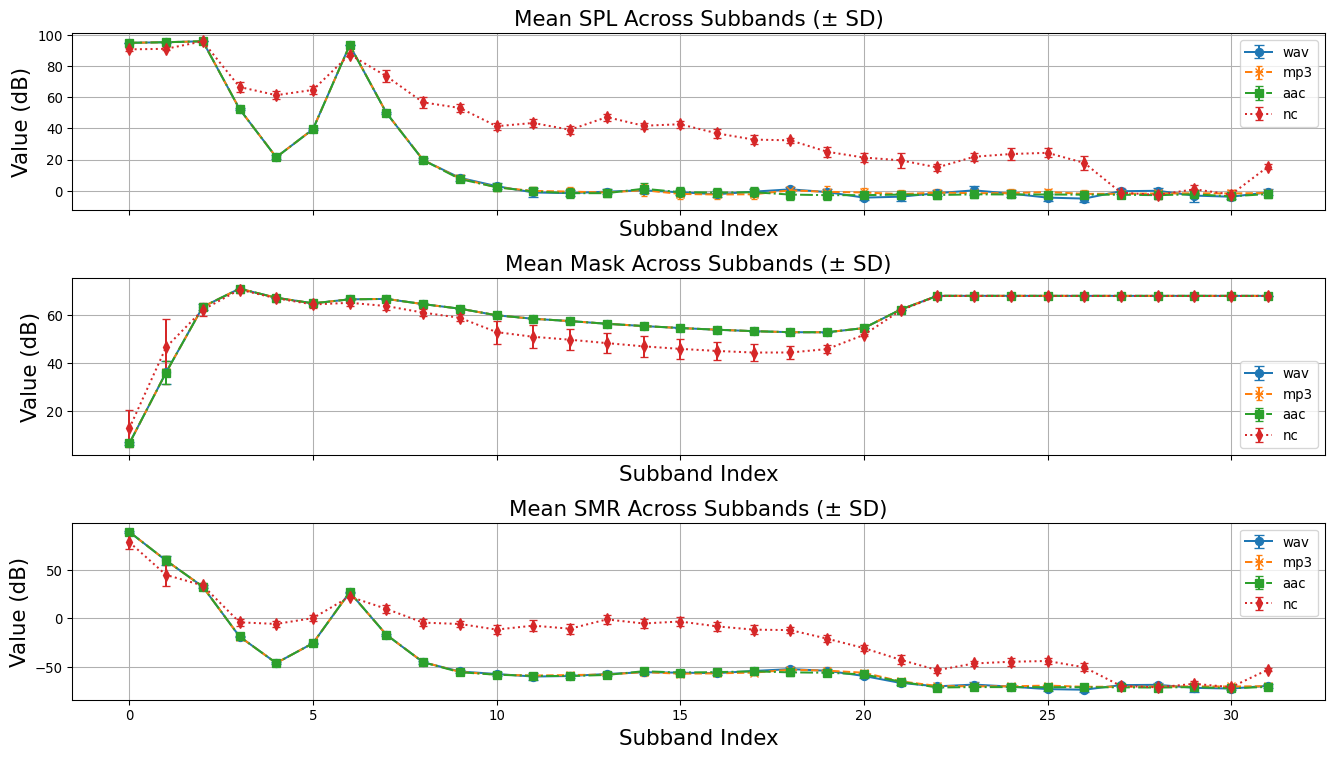

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data shapes for demonstration
data_dict = {
    "SPL": (acuum_spl_orig_wav, acuum_spl_orig_mp3, acuum_spl_orig_aac, acuum_spl_orig_nc),
    "Mask": (acuum_mask_degr_wav, acuum_mask_degr_mp3, acuum_mask_degr_aac, acuum_mask_degr_nc),
    "SMR": (acuum_smr_orig_wav, acuum_smr_orig_mp3, acuum_smr_orig_aac, acuum_smr_orig_nc),
}

subbands = np.arange(32)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True, dpi=96)
axes = axes.flatten()

# New line styles
styles = [
    ('wav', '-o', 4),   # solid line + circle
    ('mp3', '--x', 2),  # dashed + x
    ('aac', '-.s', 3),  # dash-dot + square
    ('nc',  ':d', 3),   # dotted + diamond
]

for i, (title, (data1, data2, data3, data4)) in enumerate(data_dict.items()):
    datasets = [data1, data2, data3, data4]

    for (label, fmt, cap), data in zip(styles, datasets):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        axes[i].errorbar(
            subbands, mean, yerr=std,
            label=label,
            fmt=fmt,
            capsize=cap,
            linewidth=1.5
        )

    axes[i].set_title(f"Mean {title} Across Subbands (± SD)", fontsize=16)
    axes[i].set_xlabel("Subband Index",fontsize=16)
    axes[i].set_ylabel("Value (dB)",fontsize=16)
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
#plt.suptitle("SPL, Mask, and SMR Comparison", fontsize=16, y=1.01)
plt.show()


### Only SPL SMR Full Figures

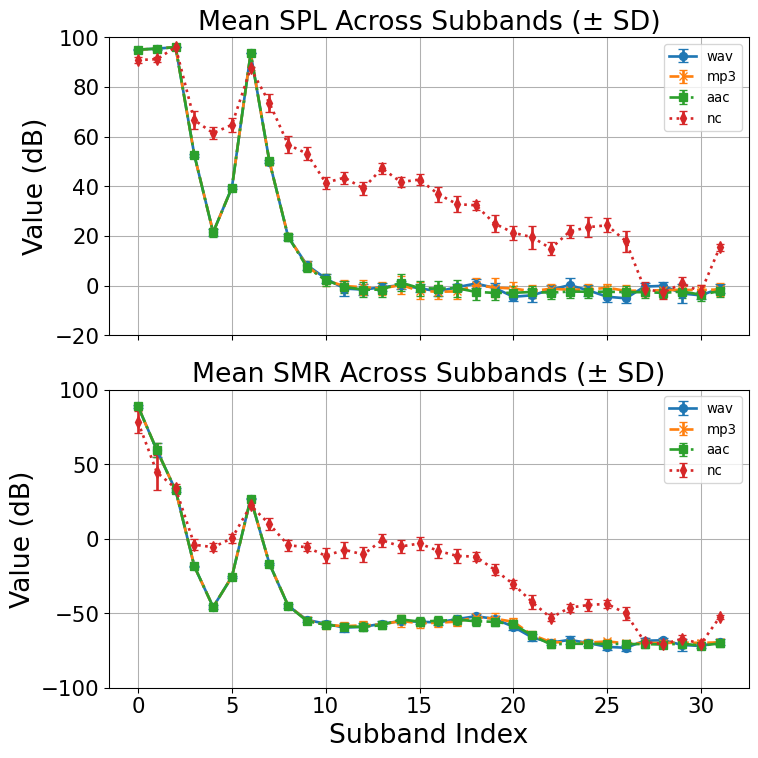

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data shapes for demonstration
data_dict = {
    "SPL": (acuum_spl_orig_wav, acuum_spl_orig_mp3, acuum_spl_orig_aac, acuum_spl_orig_nc),
#    "Mask": (acuum_mask_degr_wav, acuum_mask_degr_mp3, acuum_mask_degr_aac, acuum_mask_degr_nc),
    "SMR": (acuum_smr_orig_wav, acuum_smr_orig_mp3, acuum_smr_orig_aac, acuum_smr_orig_nc),
}

subbands = np.arange(32)
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, dpi=96)
axes = axes.flatten()

# New line styles
styles = [
    ('wav', '-o', 4),   # solid line + circle
    ('mp3', '--x', 3),  # dashed + x
    ('aac', '-.s', 3),  # dash-dot + square
    ('nc',  ':d', 3),   # dotted + diamond
]

for i, (title, (data1, data2, data3, data4)) in enumerate(data_dict.items()):
    datasets = [data1, data2, data3, data4]

    for (label, fmt, cap), data in zip(styles, datasets):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        axes[i].errorbar(
            subbands, mean, yerr=std,
            label=label,
            fmt=fmt,
            capsize=cap,
            linewidth=2
        )

    axes[i].set_title(f"Mean {title} Across Subbands (± SD)", fontsize=20)
    axes[i].set_ylabel("Value (dB)",fontsize=20)
    axes[i].tick_params(axis='both', labelsize=16)
    axes[i].grid(True)
    axes[i].legend()

axes[i].set_xlabel("Subband Index",fontsize=20)
axes[0].set_ylim(-20, 100)
axes[1].set_ylim(-100, 100)


plt.tight_layout()
#plt.suptitle("SPL, Mask, and SMR Comparison", fontsize=16, y=1.01)
plt.show()


## Degradation Plot

### Full Figures

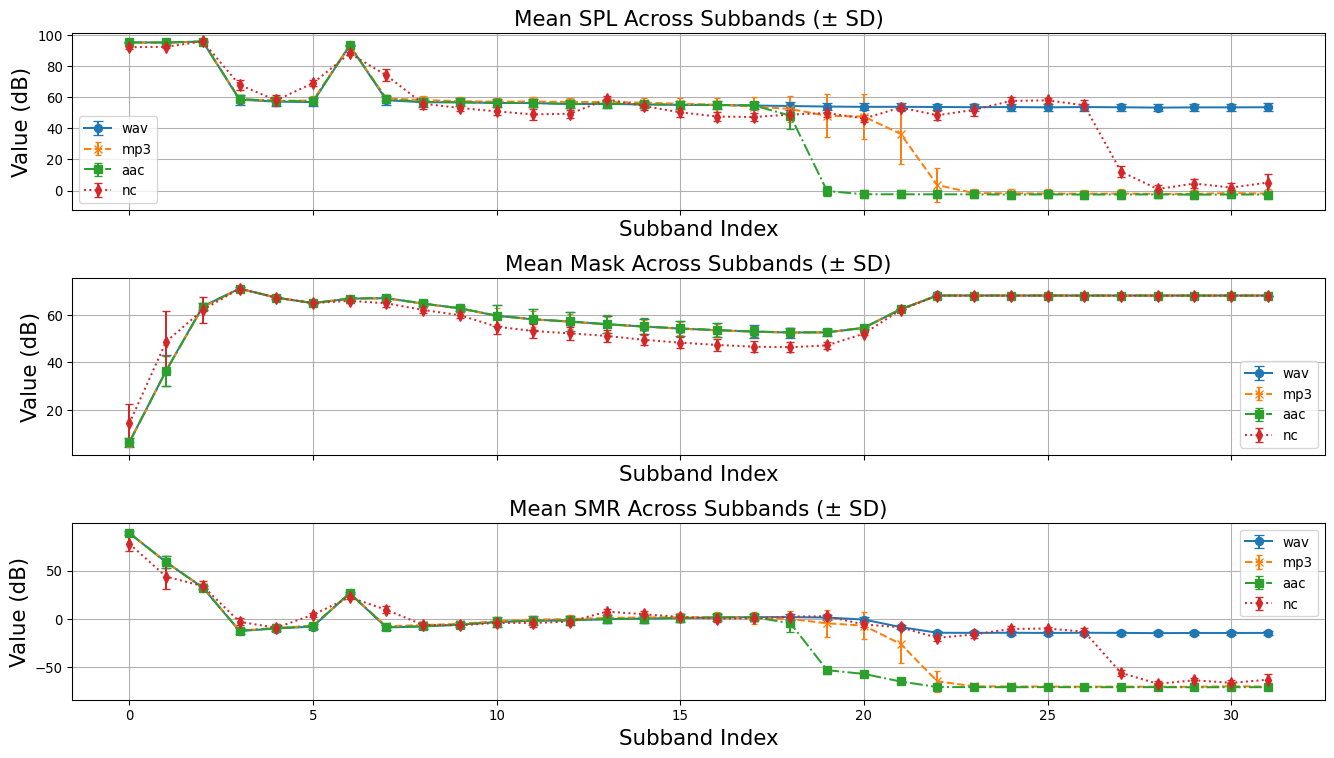

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data shapes for demonstration
data_dict = {
    "SPL": (acuum_spl_orig_wav_deg, acuum_spl_orig_mp3_deg, acuum_spl_orig_aac_deg, acuum_spl_orig_nc_deg),
    "Mask": (acuum_mask_degr_wav_deg, acuum_mask_degr_mp3_deg, acuum_mask_degr_aac_deg, acuum_mask_degr_nc_deg),
    "SMR": (acuum_smr_orig_wav_deg, acuum_smr_orig_mp3_deg, acuum_smr_orig_aac_deg, acuum_smr_orig_nc_deg),
}

subbands = np.arange(32)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True, dpi=96)
axes = axes.flatten()

# New line styles
styles = [
    ('wav', '-o', 4),   # solid line + circle
    ('mp3', '--x', 2),  # dashed + x
    ('aac', '-.s', 3),  # dash-dot + square
    ('nc',  ':d', 3),   # dotted + diamond
]

for i, (title, (data1, data2, data3, data4)) in enumerate(data_dict.items()):
    datasets = [data1, data2, data3, data4]

    for (label, fmt, cap), data in zip(styles, datasets):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        axes[i].errorbar(
            subbands, mean, yerr=std,
            label=label,
            fmt=fmt,
            capsize=cap,
            linewidth=1.5
        )

    axes[i].set_title(f"Mean {title} Across Subbands (± SD)", fontsize=16)
    axes[i].set_xlabel("Subband Index",fontsize=16)
    axes[i].set_ylabel("Value (dB)",fontsize=16)
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
#plt.suptitle("SPL, Mask, and SMR Comparison", fontsize=16, y=1.01)
plt.show()


### Only SPL SMR Full Figures

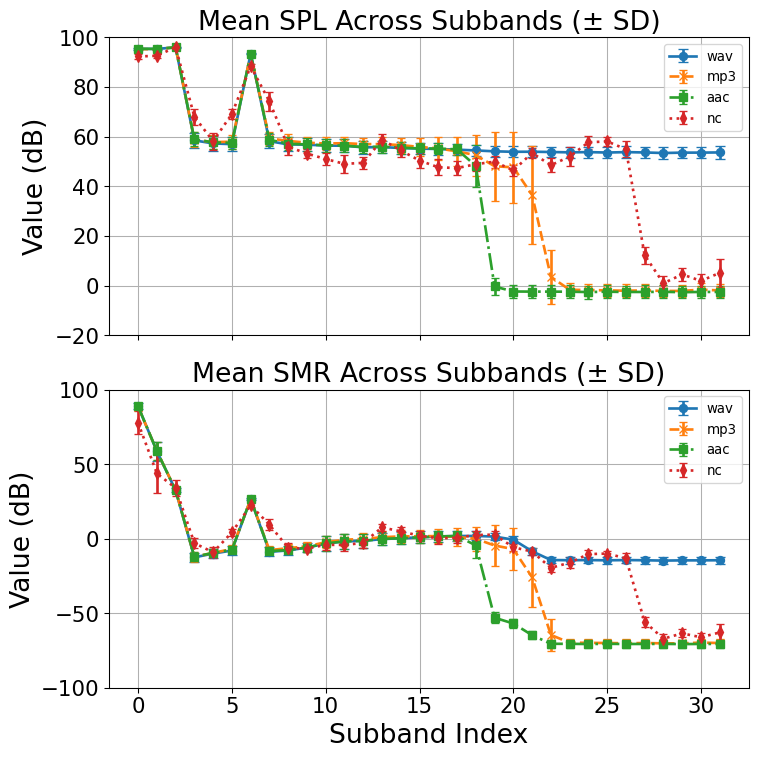

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data shapes for demonstration
data_dict = {
    "SPL": (acuum_spl_orig_wav_deg, acuum_spl_orig_mp3_deg, acuum_spl_orig_aac_deg, acuum_spl_orig_nc_deg),
#    "Mask": (acuum_mask_degr_wav_deg, acuum_mask_degr_mp3_deg, acuum_mask_degr_aac_deg, acuum_mask_degr_nc_deg),
    "SMR": (acuum_smr_orig_wav_deg, acuum_smr_orig_mp3_deg, acuum_smr_orig_aac_deg, acuum_smr_orig_nc_deg),
}

subbands = np.arange(32)
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, dpi=96)
axes = axes.flatten()

# New line styles
styles = [
    ('wav', '-o', 4),   # solid line + circle
    ('mp3', '--x', 3),  # dashed + x
    ('aac', '-.s', 3),  # dash-dot + square
    ('nc',  ':d', 3),   # dotted + diamond
]

for i, (title, (data1, data2, data3, data4)) in enumerate(data_dict.items()):
    datasets = [data1, data2, data3, data4]

    for (label, fmt, cap), data in zip(styles, datasets):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        axes[i].errorbar(
            subbands, mean, yerr=std,
            label=label,
            fmt=fmt,
            capsize=cap,
            linewidth=2
        )

    axes[i].set_title(f"Mean {title} Across Subbands (± SD)", fontsize=20)
    axes[i].set_ylabel("Value (dB)",fontsize=20)

    axes[i].tick_params(axis='both', labelsize=16)
    axes[i].grid(True)
    axes[i].legend()

axes[i].set_xlabel("Subband Index",fontsize=20)
axes[0].set_ylim(-20, 100)
axes[1].set_ylim(-100, 100)

plt.tight_layout()
#plt.suptitle("SPL, Mask, and SMR Comparison", fontsize=16, y=1.01)
plt.show()


# NMR Calculation

## MP3

In [28]:
Evaluator.extract_total_nmr(MusicMix_Referece_File, Referece_MP3File)

-23.397145

In [29]:
Evaluator.extract_total_nmr(gener_Audio, gener_Audio_mp3)

-8.291486

## AAC

In [30]:
Evaluator.extract_total_nmr(MusicMix_Referece_File, Referece_AACFile)

-36.82519

In [31]:
Evaluator.extract_total_nmr(gener_Audio, gener_Audio_aac)

-8.880225

## ENCODEC

In [32]:
Evaluator.extract_total_nmr(MusicMix_Referece_File, Referece_NeuralFile)

10.185973

In [33]:
Evaluator.extract_total_nmr(gener_Audio, gener_Audio_Neural)

3.165602